In [216]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # Vecinos más cercanos para clasificación
from sklearn.metrics import accuracy_score, classification_report # Métrica de evaluación
from sklearn.preprocessing import StandardScaler

# Análisis Exploratorio

In [217]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
df_smokers.head(5)

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0


In [218]:
# verificamos los tipos de datos
df_smokers.dtypes

age                      int64
height(cm)               int64
weight(kg)               int64
waist(cm)              float64
eyesight(left)         float64
eyesight(right)        float64
hearing(left)            int64
hearing(right)           int64
systolic                 int64
relaxation               int64
fasting blood sugar      int64
Cholesterol              int64
triglyceride             int64
HDL                      int64
LDL                      int64
hemoglobin             float64
Urine protein            int64
serum creatinine       float64
AST                      int64
ALT                      int64
Gtp                      int64
dental caries            int64
smoking                  int64
dtype: object

In [219]:
print("Tamaño del dataframe : {}".format(df_smokers.shape))

Tamaño del dataframe : (38984, 23)


In [220]:
# Verificamos si hay valores nulos para imputar
df_smokers.isnull().sum()

age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64

smoking
0    24666
1    14318
Name: count, dtype: int64


<Axes: xlabel='smoking', ylabel='count'>

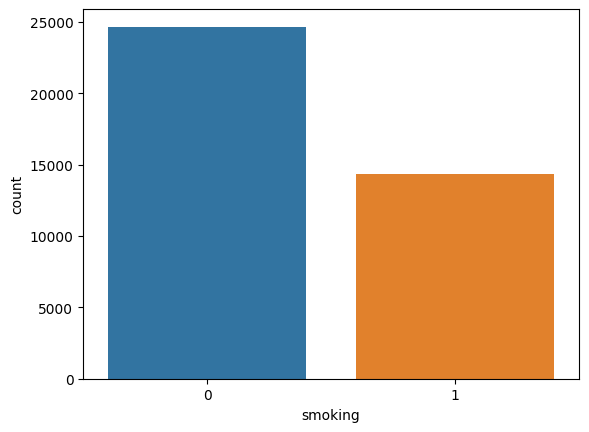

In [221]:
# Analisis de la distribución de la variable target "smoking"
print( df_smokers.smoking.value_counts() )
sns.countplot(x='smoking', data=df_smokers, hue='smoking', legend=False)

[]

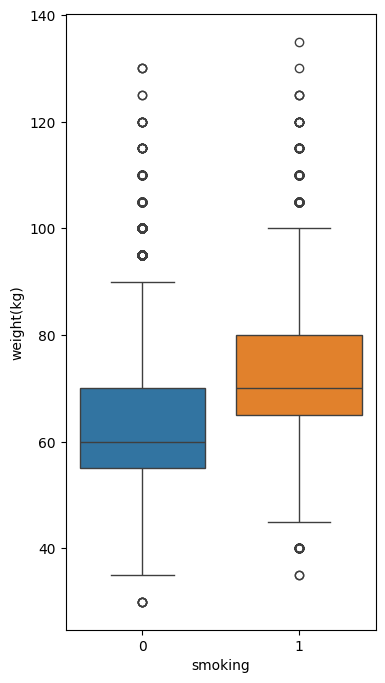

In [222]:
plt.figure(figsize=(4, 8))
s=sns.boxplot(x="smoking", y="weight(kg)", data=df_smokers, hue="smoking", legend=False)
s.plot()

# Correlación de Variables

<Axes: >

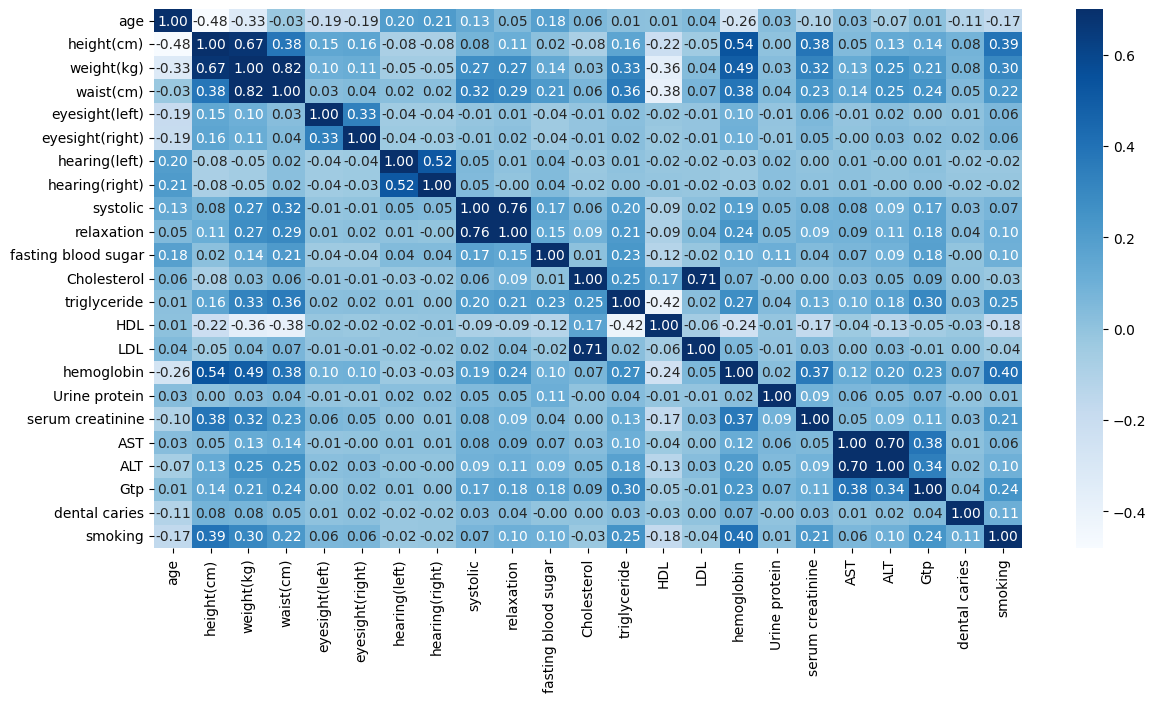

In [223]:
plt.figure(figsize=(14,7))
sns.heatmap(df_smokers.corr(), annot=True, vmax=.7, cmap ='Blues', fmt=".2f")

In [224]:
df_smokers_corr = df_smokers.corr()[["smoking"]]*100 # lo pasamos a porcentajes
df_smokers_corr = df_smokers_corr.drop("smoking", axis=0) # eliminamos la variable target
df_smokers_corr = df_smokers_corr.sort_values(["smoking"], ascending=False) # ordenamos en forma descendente
df_smokers_corr = abs(df_smokers_corr) # nos interesa el valor absouluto
df_smokers_corr

,smoking
hemoglobin,40.120561
height(cm),39.431445
weight(kg),29.934668
triglyceride,25.105661
Gtp,24.027443
waist(cm),22.335903
serum creatinine,21.247301
dental caries,10.760060
relaxation,10.366297
fasting blood sugar,9.990846


# Seleccionamos y Escalamos las variables que vamos a utilizar

In [225]:
# definimos df con las 10 columnas que elegimos para el modelo
# sería lo mismo que hacer un drop de las que no queremos
df = df_smokers[['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp',
       'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
       'fasting blood sugar','smoking']]

In [226]:
# Hacemos el Split 70-30 para train-test
y_smokers = df["smoking"]
X_train, X_test, y_train, y_test = train_test_split(df.drop(["smoking"],axis = 1), y_smokers, test_size=0.3, stratify = y_smokers, random_state=42)

In [227]:
# usamos StandardScaler para escalar las variables
scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

,copy,True
,with_mean,True
,with_std,True


In [228]:
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

In [229]:
test_scores = []

# Creamos y entrenamos el algoritmo con 20 valores de K
for k in range(3,40,2):
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  test_scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación

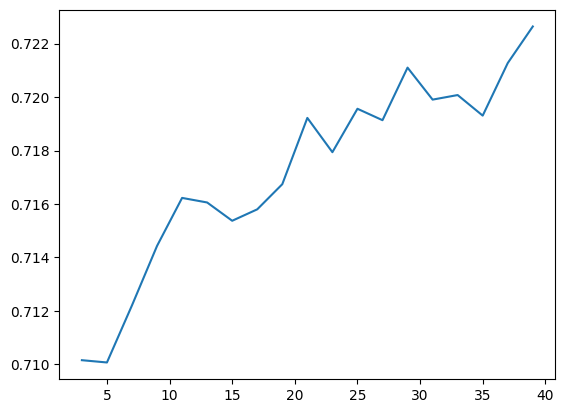

In [230]:
df_scores = pd.DataFrame([{"k":valor_k, "score":test_scores_k} for valor_k, test_scores_k in zip(range(3,40,2),test_scores)])
plt.plot(df_scores["k"], df_scores["score"])

In [231]:
df_scores

,k,score
0,3,0.710157
1,5,0.710072
2,7,0.712209
3,9,0.714432
4,11,0.716228
5,13,0.716057
6,15,0.715373
7,17,0.715800
8,19,0.716741
9,21,0.719220


In [232]:
# Entrenamos el algoritmo con el mejor K
knn = KNeighborsClassifier( 11 )
knn.fit(X_train,y_train) # Entrenamos el clasificador

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [233]:
y_pred_knn = knn.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

Exactitud (accuracy) del modelo: 71.62 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      7400
           1       0.62      0.61      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.69      0.69      0.69     11696
weighted avg       0.72      0.72      0.72     11696



---
# Ejercicio KNN

Dado el análisis exploratorio concluimos que no hace falta imputar variables y que la variable target esta balanceada.

---
## Ejercicio 1

Usando el mapa de calor de correlaciones, ¿que pares de columnas comparten más de un 0.7 de correlación?

### 1.1 - Matriz de Correlación

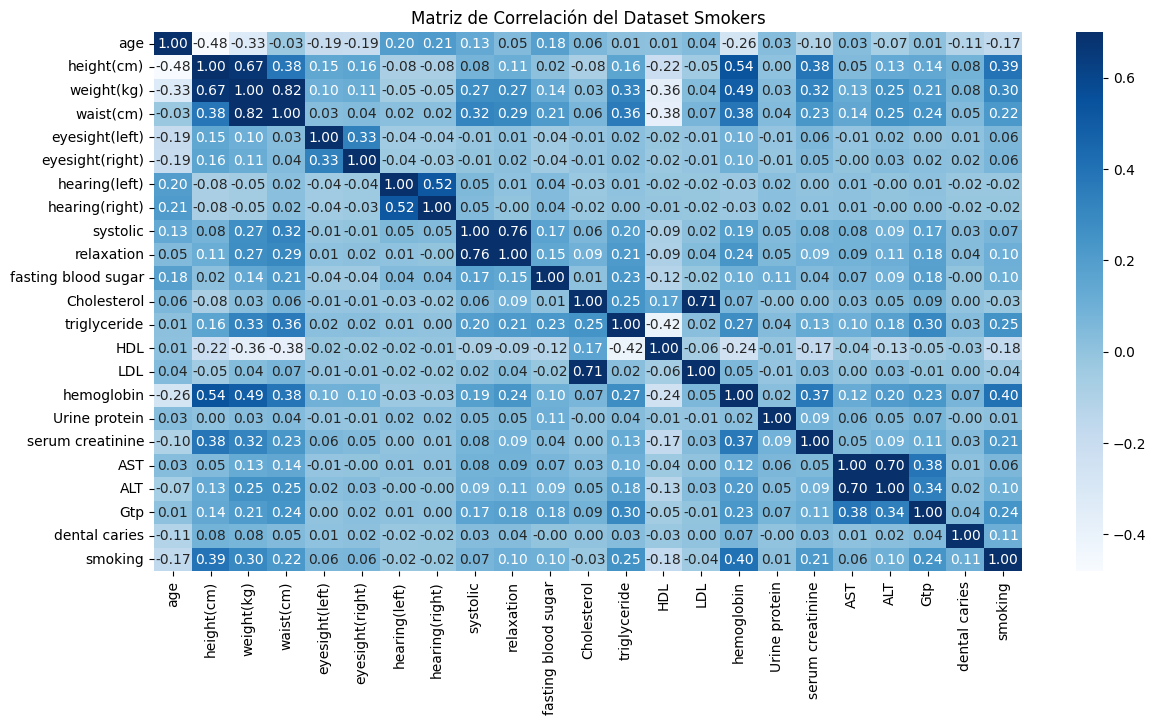

In [234]:
correlation_matrix = df_smokers.corr()
plt.figure(figsize=(14,7))
sns.heatmap(correlation_matrix, annot=True, vmax=.7, cmap ='Blues', fmt=".2f")
plt.title('Matriz de Correlación del Dataset Smokers')
plt.show()

### 1.2 - Buscar pares con correlación >= 0.7

#### 1.2.1 - Obtener matriz de correlación absoluta

In [235]:
matriz_correlacion = df_smokers.corr().abs()

#### 1.2.2 - Crear máscara para evitar diagonal y duplicados

In [236]:
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))
matriz_correlacion = matriz_correlacion.mask(mask)

#### 1.2.3 - Encontrar pares con correlación >= 0.7

In [237]:
pares_alta_correlacion = []
for col in matriz_correlacion.columns:
    for idx in matriz_correlacion.index:
        if matriz_correlacion.loc[idx, col] >= 0.7:
            valor = matriz_correlacion.loc[idx, col]
            pares_alta_correlacion.append((idx, col, valor))

print("Pares de variables con correlación >= 0.7:")
print("=" * 60)
if pares_alta_correlacion:
    for var1, var2, corr in pares_alta_correlacion:
        print(f"{var1:<25} - {var2:<25}: {corr:.3f}")
else:
    print("No se encontraron pares con correlación >= 0.7")

Pares de variables con correlación >= 0.7:
waist(cm)                 - weight(kg)               : 0.825
relaxation                - systolic                 : 0.759
LDL                       - Cholesterol              : 0.707


---
## Ejercicio 2

Entrenar un modelo con K menor a 11, comparar los resultados

### 2.1 - Probamos con K=5

In [238]:
k_menor = 5
knn_menor = KNeighborsClassifier(k_menor)
knn_menor.fit(X_train, y_train)

y_pred_menor = knn_menor.predict(X_test)
accuracy_menor = accuracy_score(y_test, y_pred_menor)

print(f"Resultados con K = {k_menor}:")
print(f"Exactitud: {accuracy_menor:.4f} ({accuracy_menor*100:.2f}%)")

Resultados con K = 5:
Exactitud: 0.7101 (71.01%)


### 2.2 - Reporte de Clasificación

In [239]:
print(classification_report(y_test, y_pred_menor))

              precision    recall  f1-score   support

           0       0.77      0.78      0.77      7400
           1       0.61      0.59      0.60      4296

    accuracy                           0.71     11696
   macro avg       0.69      0.68      0.69     11696
weighted avg       0.71      0.71      0.71     11696



### 2.3 - Comparación con K=11

In [240]:
accuracy_original = accuracy_score(y_test, y_pred_knn)
print(f"K = {k_menor}: {accuracy_menor:.4f}")
print(f"K = 11: {accuracy_original:.4f}")
print(f"Diferencia: {(accuracy_menor - accuracy_original):.4f}")

K = 5: 0.7101
K = 11: 0.7162
Diferencia: -0.0062


---
## Ejercicio 3

Entrenar un modelo con K mayor a 11, comparar los resultados

### 3.1 - Probamos con K=21

In [241]:
k_mayor = 21
knn_mayor = KNeighborsClassifier(k_mayor)
knn_mayor.fit(X_train, y_train)

y_pred_mayor = knn_mayor.predict(X_test)
accuracy_mayor = accuracy_score(y_test, y_pred_mayor)

print(f"Resultados con K = {k_mayor}:")
print(f"Exactitud: {accuracy_mayor:.4f} ({accuracy_mayor*100:.2f}%)")

Resultados con K = 21:
Exactitud: 0.7192 (71.92%)


### 3.2 - Reporte de Clasificación

In [242]:
print(classification_report(y_test, y_pred_mayor))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78      7400
           1       0.62      0.61      0.62      4296

    accuracy                           0.72     11696
   macro avg       0.70      0.70      0.70     11696
weighted avg       0.72      0.72      0.72     11696



### 3.3 - Comparación con K=11

In [243]:
print(f"K = {k_mayor}: {accuracy_mayor:.4f}")
print(f"K = 11: {accuracy_original:.4f}")
print(f"Diferencia: {(accuracy_mayor - accuracy_original):.4f}")

K = 21: 0.7192
K = 11: 0.7162
Diferencia: 0.0030


---
## Ejercicio 4

Entrenar un modelo con 3 variables, seleccionar un K apropiado y comparar los resultados

### 4.1 - Seleccionar las 3 variables más correlacionadas con smoking

In [244]:
df_smokers_corr = df_smokers.corr()[["smoking"]].abs()
df_smokers_corr = df_smokers_corr.drop("smoking", axis=0)
df_smokers_corr = df_smokers_corr.sort_values(["smoking"], ascending=False)

### 4.2 - Obtener las 3 variables más correlacionadas

In [245]:
top_3_vars = df_smokers_corr.head(3).index.tolist()
print(f"Top 3 variables más correlacionadas con smoking:")
for i, var in enumerate(top_3_vars, 1):
    corr_value = df_smokers_corr.loc[var, 'smoking']
    print(f"{i}. {var}: {corr_value:.4f}")

Top 3 variables más correlacionadas con smoking:
1. hemoglobin: 0.4012
2. height(cm): 0.3943
3. weight(kg): 0.2993


### 4.3 - Preparar datos con solo 3 variables

In [246]:
X_train_3vars = scaler_X.fit_transform(df.drop(["smoking"], axis=1)[top_3_vars].loc[X_train.index if hasattr(X_train, 'index') else range(len(X_train))])
X_test_3vars = scaler_X.transform(df.drop(["smoking"], axis=1)[top_3_vars].loc[X_test.index if hasattr(X_test, 'index') else range(len(X_test))])

### 4.4 - Buscar mejor K para 3 variables

In [247]:
test_scores_3vars = []
k_range = range(3, 31, 2)

for k in k_range:
    knn_3vars = KNeighborsClassifier(k)
    knn_3vars.fit(X_train_3vars, y_train)
    y_pred_3vars = knn_3vars.predict(X_test_3vars)
    test_scores_3vars.append(accuracy_score(y_test, y_pred_3vars))

### 4.5 - Encontrar mejor K

In [248]:
best_k_idx = test_scores_3vars.index(max(test_scores_3vars))
best_k_3vars = list(k_range)[best_k_idx]
best_accuracy_3vars = max(test_scores_3vars)

print(f"Mejor K para 3 variables: {best_k_3vars}")
print(f"Mejor exactitud: {best_accuracy_3vars:.4f} ({best_accuracy_3vars*100:.2f}%)")

Mejor K para 3 variables: 29
Mejor exactitud: 0.6135 (61.35%)


### 4.6 - Entrenar modelo final con mejor K

In [249]:
knn_final_3vars = KNeighborsClassifier(best_k_3vars)
knn_final_3vars.fit(X_train_3vars, y_train)
y_pred_final_3vars = knn_final_3vars.predict(X_test_3vars)

### 4.7 - Reporte de clasificación (3 variables)

In [250]:
print(classification_report(y_test, y_pred_final_3vars))

              precision    recall  f1-score   support

           0       0.63      0.93      0.75      7400
           1       0.36      0.07      0.12      4296

    accuracy                           0.61     11696
   macro avg       0.50      0.50      0.44     11696
weighted avg       0.53      0.61      0.52     11696



### 4.8 - Comparación con modelo original (10 variables)

In [251]:
print(f"3 variables (K={best_k_3vars}): {best_accuracy_3vars:.4f}")
print(f"10 variables (K=11): {accuracy_original:.4f}")
print(f"Diferencia: {(best_accuracy_3vars - accuracy_original):.4f}")

3 variables (K=29): 0.6135
10 variables (K=11): 0.7162
Diferencia: -0.1028


---
## Ejercicio 5

**Feature Engineering**: Crear una columna nueva no redundante, entrenar un modelo y comparar los resultados

### 5.1 - Crear DataFrame con las variables originales

In [252]:
df_feature_eng = df_smokers.copy()

### 5.2 - Crear nuevas variables derivadas

In [253]:
# 1. IMC (Índice de Masa Corporal)
df_feature_eng['BMI'] = df_feature_eng['weight(kg)'] / ((df_feature_eng['height(cm)'] / 100) ** 2)

# 2. Ratio cintura-altura
df_feature_eng['waist_height_ratio'] = df_feature_eng['waist(cm)'] / df_feature_eng['height(cm)']

# 3. Variable categórica de edad
df_feature_eng['age_group'] = pd.cut(df_feature_eng['age'], bins=[0, 30, 45, 60, 100], labels=[0, 1, 2, 3])

print("Nuevas variables creadas:")
print("1. BMI (Índice de Masa Corporal)")
print("2. waist_height_ratio (Ratio cintura-altura)")  
print("3. age_group (Grupo etario categórico)")

Nuevas variables creadas:
1. BMI (Índice de Masa Corporal)
2. waist_height_ratio (Ratio cintura-altura)
3. age_group (Grupo etario categórico)


### 5.3 - Seleccionar variables para el modelo (originales + nuevas)

In [254]:
feature_cols = ['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp', 'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation', 'fasting blood sugar', 'BMI', 'waist_height_ratio', 'age_group']

### 5.4 - Preparar datos, Split y Escalar

In [255]:
X_feature_eng = df_feature_eng[feature_cols]
y_feature_eng = df_feature_eng['smoking']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_feature_eng, y_feature_eng, test_size=0.3, stratify=y_feature_eng, random_state=42)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

### 5.5 - Buscar mejor K

In [256]:
test_scores_fe = []
for k in range(3, 31, 2):
    knn_fe = KNeighborsClassifier(k)
    knn_fe.fit(X_train_fe_scaled, y_train_fe)
    y_pred_fe = knn_fe.predict(X_test_fe_scaled)
    test_scores_fe.append(accuracy_score(y_test_fe, y_pred_fe))

### 5.6 - Mejor K

In [257]:
best_k_fe_idx = test_scores_fe.index(max(test_scores_fe))
best_k_fe = list(range(3, 31, 2))[best_k_fe_idx]
best_accuracy_fe = max(test_scores_fe)

### 5.7 - Modelo final

In [258]:
knn_final_fe = KNeighborsClassifier(best_k_fe)
knn_final_fe.fit(X_train_fe_scaled, y_train_fe)
y_pred_final_fe = knn_final_fe.predict(X_test_fe_scaled)

print(f"Mejor K con Feature Engineering: {best_k_fe}")
print(f"Exactitud: {best_accuracy_fe:.4f} ({best_accuracy_fe*100:.2f}%)")

Mejor K con Feature Engineering: 29
Exactitud: 0.7282 (72.82%)


### 5.8 - Reporte de clasificación (con Feature Engineering)

In [259]:
print(classification_report(y_test_fe, y_pred_final_fe))

              precision    recall  f1-score   support

           0       0.78      0.79      0.79      7400
           1       0.63      0.62      0.63      4296

    accuracy                           0.73     11696
   macro avg       0.71      0.71      0.71     11696
weighted avg       0.73      0.73      0.73     11696



### 5.9 - Comparación

In [260]:
print(f"Con Feature Engineering (K={best_k_fe}): {best_accuracy_fe:.4f}")
print(f"Modelo original (K=11): {accuracy_original:.4f}")
print(f"Mejora: {(best_accuracy_fe - accuracy_original):.4f}")

Con Feature Engineering (K=29): 0.7282
Modelo original (K=11): 0.7162
Mejora: 0.0120


---
## Ejercicio 6

Entrenar un modelo con todas las variables, seleccionar un K apropiado y comparar los resultados

### 6.1 - Usar todas las variables excepto 'smoking'

In [261]:
all_features = [col for col in df_smokers.columns if col != 'smoking']
print(f"Número total de variables: {len(all_features)}")
print(f"Variables utilizadas: {all_features}")

Número total de variables: 22
Variables utilizadas: ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries']


### 6.2 - Preparar datos con todas las variables, Split y Escalar

In [262]:
X_all = df_smokers[all_features]
y_all = df_smokers['smoking']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.3, stratify=y_all, random_state=42)

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

### 6.3 - Buscar mejor K

In [263]:
test_scores_all = []
k_range_all = range(3, 41, 2)

for k in k_range_all:
    knn_all = KNeighborsClassifier(k)
    knn_all.fit(X_train_all_scaled, y_train_all)
    y_pred_all = knn_all.predict(X_test_all_scaled)
    test_scores_all.append(accuracy_score(y_test_all, y_pred_all))

### 6.4 - Visualizar scores

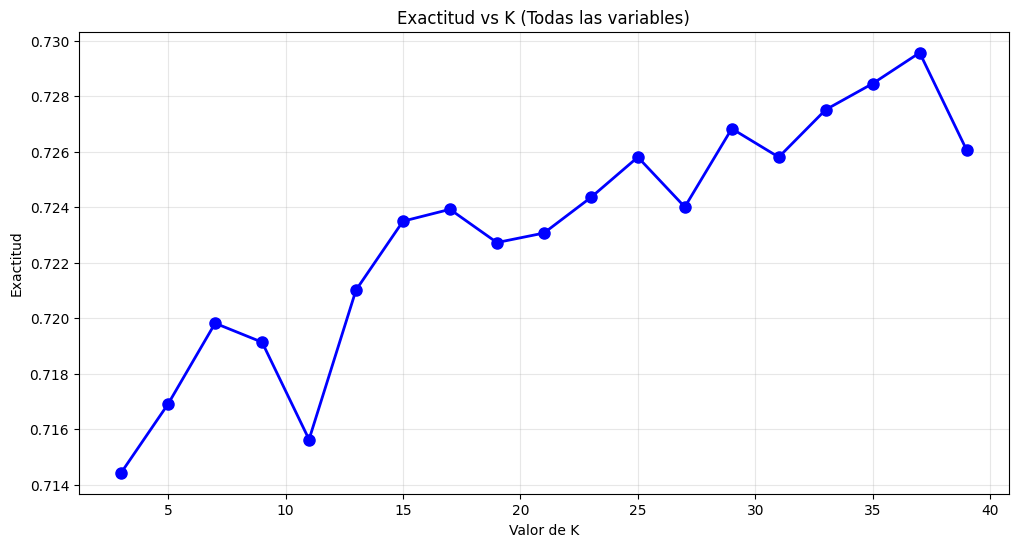

In [264]:
plt.figure(figsize=(12, 6))
plt.plot(list(k_range_all), test_scores_all, 'bo-', linewidth=2, markersize=8)
plt.title('Exactitud vs K (Todas las variables)')
plt.xlabel('Valor de K')
plt.ylabel('Exactitud')
plt.grid(True, alpha=0.3)
plt.show()

### 6.5 - Mejor K

In [265]:
best_k_all_idx = test_scores_all.index(max(test_scores_all))
best_k_all = list(k_range_all)[best_k_all_idx]
best_accuracy_all = max(test_scores_all)

### 6.6 - Modelo final

In [266]:
knn_final_all = KNeighborsClassifier(best_k_all)
knn_final_all.fit(X_train_all_scaled, y_train_all)
y_pred_final_all = knn_final_all.predict(X_test_all_scaled)

print(f"Mejor K con todas las variables: {best_k_all}")
print(f"Exactitud: {best_accuracy_all:.4f} ({best_accuracy_all*100:.2f}%)")

Mejor K con todas las variables: 37
Exactitud: 0.7296 (72.96%)


### 6.7 - Reporte de clasificación (todas las variables)

In [267]:
print(classification_report(y_test_all, y_pred_final_all))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79      7400
           1       0.64      0.61      0.62      4296

    accuracy                           0.73     11696
   macro avg       0.71      0.70      0.71     11696
weighted avg       0.73      0.73      0.73     11696



## Resumen comparativo final de todos los modelos

In [268]:
resultados = [
    ("Modelo original (10 vars, K=11)", accuracy_original),
    (f"K menor (K={k_menor})", accuracy_menor),
    (f"K mayor (K={k_mayor})", accuracy_mayor),
    (f"3 variables (K={best_k_3vars})", best_accuracy_3vars),
    (f"Feature Engineering (K={best_k_fe})", best_accuracy_fe),
    (f"Todas las variables (K={best_k_all})", best_accuracy_all)
]

Ordenar por exactitud

In [ ]:
resultados_ordenados = sorted(resultados, key=lambda x: x[1], reverse=True)

In [269]:
print(f"{'Modelo':<35} {'Exactitud':<12} {'Mejora vs Original':<20}")
print("-" * 70)
for modelo, exactitud in resultados_ordenados:
    mejora = exactitud - accuracy_original
    print(f"{modelo:<35} {exactitud:.4f}      {mejora:+.4f}")

Modelo                              Exactitud    Mejora vs Original  
----------------------------------------------------------------------
Todas las variables (K=37)          0.7296      +0.0133
Feature Engineering (K=29)          0.7282      +0.0120
K mayor (K=21)                      0.7192      +0.0030
Modelo original (10 vars, K=11)     0.7162      +0.0000
K menor (K=5)                       0.7101      -0.0062
3 variables (K=29)                  0.6135      -0.1028


In [270]:
print("Conclusiones:")
mejor_modelo = resultados_ordenados[0]
print(f"• Mejor modelo: {mejor_modelo[0]} con {mejor_modelo[1]:.4f} de exactitud")
print(f"• Mejora respecto al modelo original: {mejor_modelo[1] - accuracy_original:+.4f}")

Conclusiones:
• Mejor modelo: Todas las variables (K=37) con 0.7296 de exactitud
• Mejora respecto al modelo original: +0.0133
